# Model-free hypervolume results

This notebook contains the six Scalarized UCB experiments and a separate Scalarized KG holistic gravity pilot below.

Scalarized UCB with separate **RTS** and **STR** algorithms, using simulated rewards. The six experiments cover gravity variance, synchronization, and request-rate heterogeneity under holistic and Cheetah reductionist formulations.

Each condition has **one independent run, 100 online requests, 10 arms, and 5 directions**: 50 requests initialize every arm-direction pair and 50 requests use adaptive UCB. Holistic arms lie in $[0,1]$ and map to the active class's margin interval. Reductionist arms are Cheetah fitness margins, evenly spaced in $[-10,20]$. A pull receives only its current overhead and instability increments.

The **held-out sequence horizon is separate from the online training budget**: 100 global iterations for holistic evaluation and 50 Cheetah requests for reductionist evaluation. These evaluation horizons and fixed total-cost references match the current MORBO/qNParEGO runs:

| Formulation | Evaluation sequence length | Overhead reference (KiB) | Instability reference |
|---|---:|---:|---:|
| Holistic | 100 | 2,200,000 | 310 |
| Cheetah reductionist | 50 | 90,497.578125 | 85 |

At every online iteration, hypervolume assesses the **currently recommended arm subset**. Its exponentially large set of possible sequences is approximated by 16 sampled sequences plus each recommended arm's constant sequence, removing duplicates. Each sequence has 2 held-out realizations. The fixed 128-direction polar hypervolume calculation preserves RTS/STR ordering. Repeated subsets reuse the same held-out evaluations, which never update UCB.

Training seeds, held-out seeds, and evaluation draws are paired across conditions and formulations. These are single-run empirical estimates without confidence intervals. Curves may decrease when recommendations change; no cumulative maximum or smoothing is applied. The dotted vertical line marks the end of initialization.

Matching references and evaluation horizons does **not** yet make these a controlled ranking against Bayesian optimization: UCB's sampled sequence-set evaluation includes constant sequences, and the search budgets and evaluation protocols differ. See [experiment details](../Scalarized%20UCB/README.md).

In [1]:
from pathlib import Path
import hashlib
import json
import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import Markdown, display

root = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "Scalarized UCB" / "setup_holistic_gravity.json").is_file()), None)
if root is None:
    raise FileNotFoundError("Open this notebook from the Cosmic Octopi project.")
experiment_dir = root / "Scalarized UCB"


def load_ucb_result(approach, experiment):
    setup_file = experiment_dir / f"setup_{approach}_{experiment}.json"
    setup = json.loads(setup_file.read_text(encoding="utf-8"))
    with (experiment_dir / setup["output_file"]).open("rb") as file:
        record = pickle.load(file)
    if not record["complete"] or record["setup"] != setup:
        raise ValueError(f"Complete/update script_{approach}_{experiment}.py before plotting.")
    for relative, expected in record["source_sha256"].items():
        if hashlib.sha256((root / relative).read_bytes()).hexdigest() != expected:
            raise ValueError(f"Results predate a source change: {relative}")
    xi = json.loads((experiment_dir / setup["xi_matrix_file"]).read_text(encoding="utf-8"))
    if any(not np.array_equal(record["xi_matrices"][name], values) for name, values in xi.items()):
        raise ValueError("The Xi matrices changed; rerun this experiment before plotting.")
    return record


def plot_ucb_hypervolume(record, formulation):
    setup, approach = record["setup"], record["approach"]
    sweep = setup.get("sweep", {"parameter": "gamma_grav", "values": setup.get("gravity_variances"), "symbol": "grav"})
    n_online = setup["bandit"].get("n_online_iterations", setup[approach]["horizon"])
    initialization = setup["bandit"]["n_arms"] * setup["bandit"]["n_scalarization_directions"]
    all_hv = np.concatenate([np.asarray(r["hypervolume_history"]) for r in record["runs"].values()])
    padding = max(0.005, 0.08 * np.ptp(all_hv))
    fig, ax = plt.subplots(figsize=(6, 5))
    for color, level in zip(["#1f77b4", "#ff7f0e"], sweep["values"]):
        trajectory = record["runs"][f"{formulation}/{sweep['parameter']}={level:g}"]
        iterations = np.asarray(trajectory["checkpoint_iterations"])
        hv = np.asarray(trajectory["hypervolume_history"])
        if len(iterations) != len(hv) or iterations[-1] != n_online:
            raise ValueError("Incomplete hypervolume history")
        ax.plot(iterations, hv, color=color, linewidth=2, marker="o", markersize=4, markevery=5,
                label=r"Sc-UCB, $\gamma_{\mathrm{" + sweep["symbol"] + "}} = " + f"{level:g}" + "$")
    ax.axvline(initialization, color="0.55", linestyle=":", linewidth=1)
    ax.set_xlabel("Global iteration" if approach == "holistic" else "Cheetah request", fontsize=14)
    ax.set_ylabel("Normalized hypervolume", fontsize=14)
    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.set_xlim(1, n_online)
    ax.set_ylim(max(0, all_hv.min() - padding), all_hv.max() + padding)
    ax.grid(False)
    ax.legend(fontsize=10)
    fig.tight_layout()
    plt.show()

ucb_results = {}


## Holistic / Gravity heterogeneity

$\gamma_{\mathrm{grav}}=1$ versus $5$, with synchronization $1$ and request heterogeneity $0.5$.

100 online requests; held-out sequence length 100.

In [2]:
ucb_results["holistic_gravity"] = load_ucb_result("holistic", "gravity")

### RTS: robustify, then scalarize

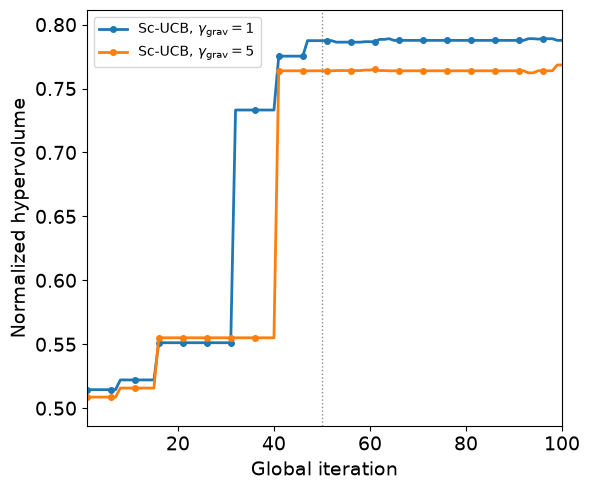

In [3]:
plot_ucb_hypervolume(ucb_results["holistic_gravity"], "RTS")

### STR: scalarize, then robustify

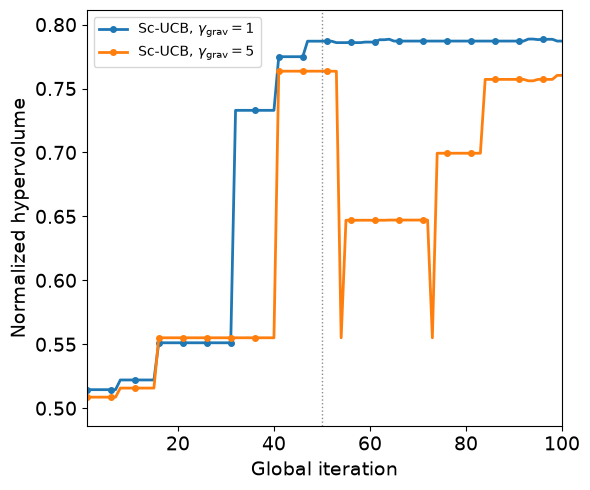

In [4]:
plot_ucb_hypervolume(ucb_results["holistic_gravity"], "STR")

## Reductionist: Cheetah / Gravity heterogeneity

$\gamma_{\mathrm{grav}}=1$ versus $5$, with synchronization $1$ and request heterogeneity $0.5$.

100 online requests; held-out sequence length 50.

In [5]:
ucb_results["reductionist_gravity"] = load_ucb_result("reductionist", "gravity")

### RTS: robustify, then scalarize

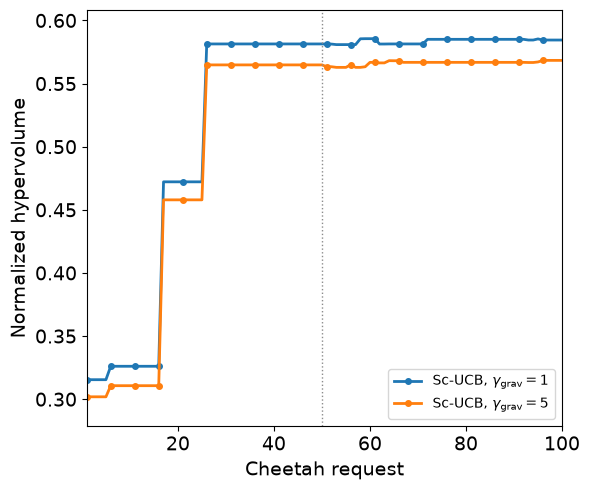

In [6]:
plot_ucb_hypervolume(ucb_results["reductionist_gravity"], "RTS")

### STR: scalarize, then robustify

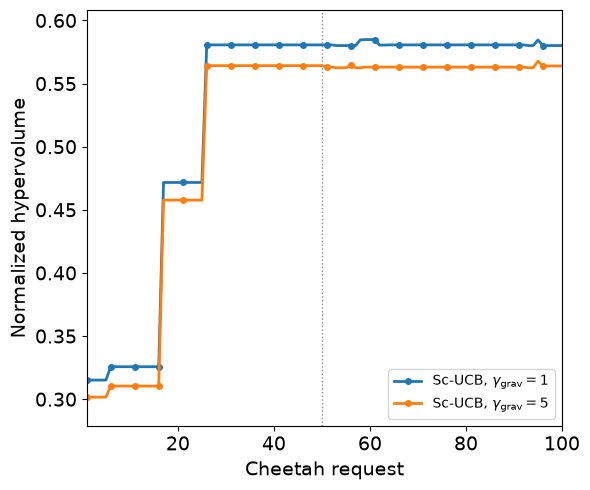

In [7]:
plot_ucb_hypervolume(ucb_results["reductionist_gravity"], "STR")

## Holistic / Synchronization

$\gamma_{\mathrm{sync}}=1$ versus $0.8$, with gravity variance $0.1$ and request heterogeneity $0.5$.

100 online requests; held-out sequence length 100.

In [8]:
ucb_results["holistic_synchronization"] = load_ucb_result("holistic", "synchronization")

### RTS: robustify, then scalarize

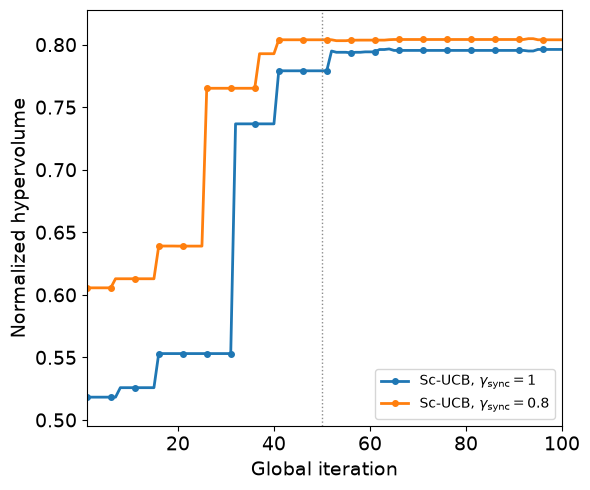

In [9]:
plot_ucb_hypervolume(ucb_results["holistic_synchronization"], "RTS")

### STR: scalarize, then robustify

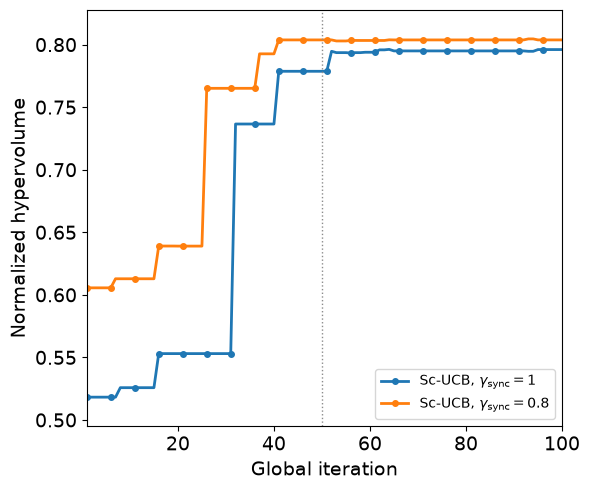

In [10]:
plot_ucb_hypervolume(ucb_results["holistic_synchronization"], "STR")

## Reductionist: Cheetah / Synchronization

$\gamma_{\mathrm{sync}}=1$ versus $0.8$, with gravity variance $0.1$ and request heterogeneity $0.5$.

100 online requests; held-out sequence length 50.

In [11]:
ucb_results["reductionist_synchronization"] = load_ucb_result("reductionist", "synchronization")

### RTS: robustify, then scalarize

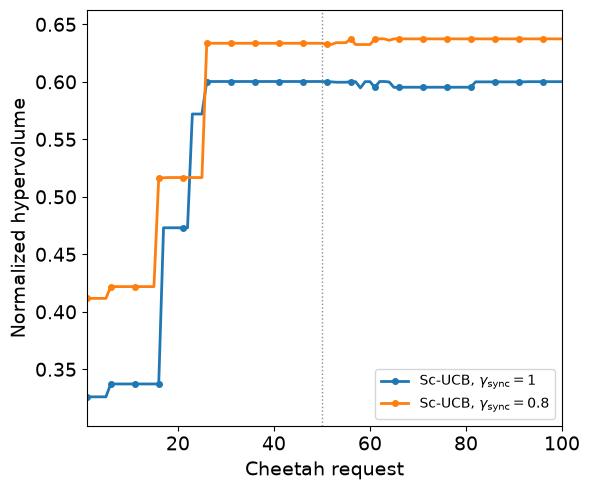

In [12]:
plot_ucb_hypervolume(ucb_results["reductionist_synchronization"], "RTS")

### STR: scalarize, then robustify

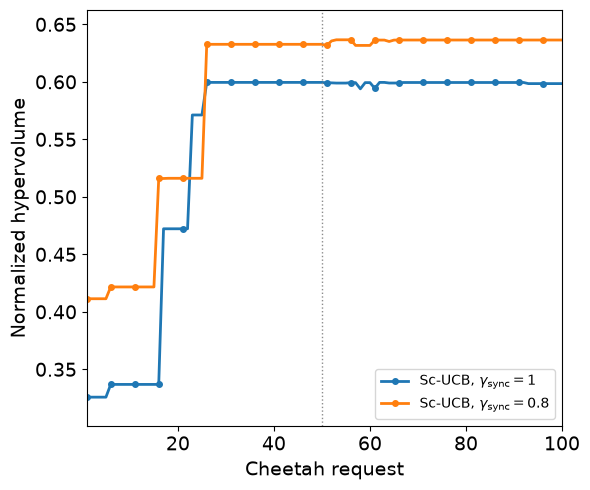

In [13]:
plot_ucb_hypervolume(ucb_results["reductionist_synchronization"], "STR")

## Holistic / Request-rate heterogeneity

$\gamma_{\mathrm{heter}}=0.1$ versus $0.8$, with gravity variance $0.1$ and synchronization $1$.

100 online requests; held-out sequence length 100.

In [14]:
ucb_results["holistic_heterogeneity"] = load_ucb_result("holistic", "heterogeneity")

### RTS: robustify, then scalarize

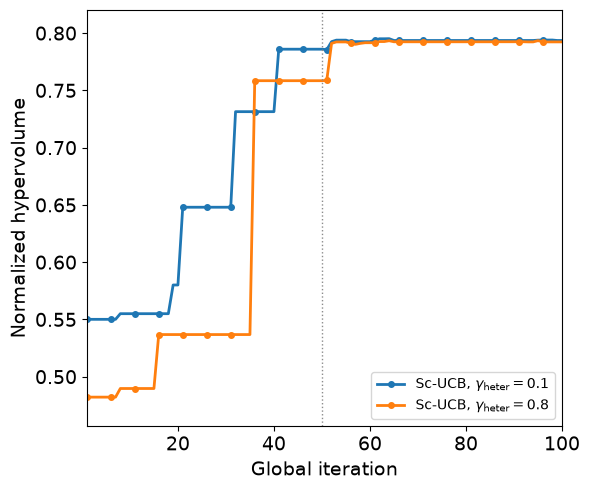

In [15]:
plot_ucb_hypervolume(ucb_results["holistic_heterogeneity"], "RTS")

### STR: scalarize, then robustify

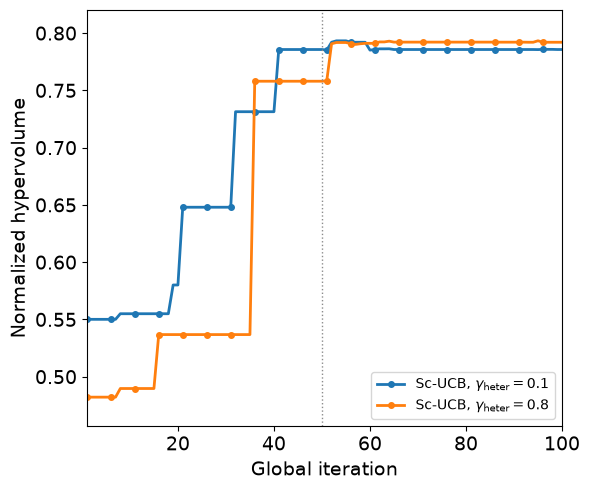

In [16]:
plot_ucb_hypervolume(ucb_results["holistic_heterogeneity"], "STR")

## Reductionist: Cheetah / Request-rate heterogeneity

$\gamma_{\mathrm{heter}}=0.1$ versus $0.8$, with gravity variance $0.1$ and synchronization $1$.

100 online requests; held-out sequence length 50.

In [17]:
ucb_results["reductionist_heterogeneity"] = load_ucb_result("reductionist", "heterogeneity")

### RTS: robustify, then scalarize

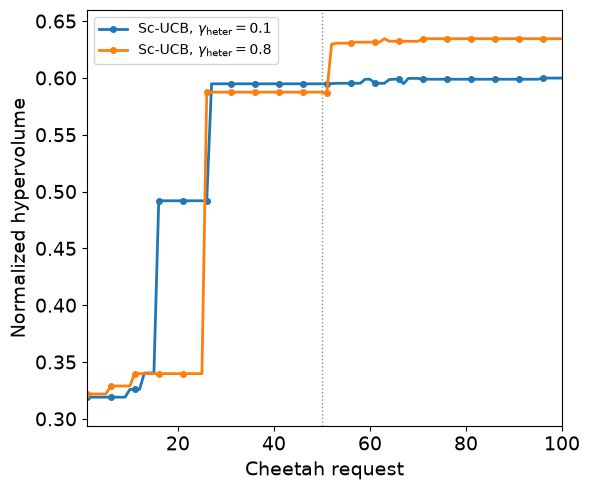

In [18]:
plot_ucb_hypervolume(ucb_results["reductionist_heterogeneity"], "RTS")

### STR: scalarize, then robustify

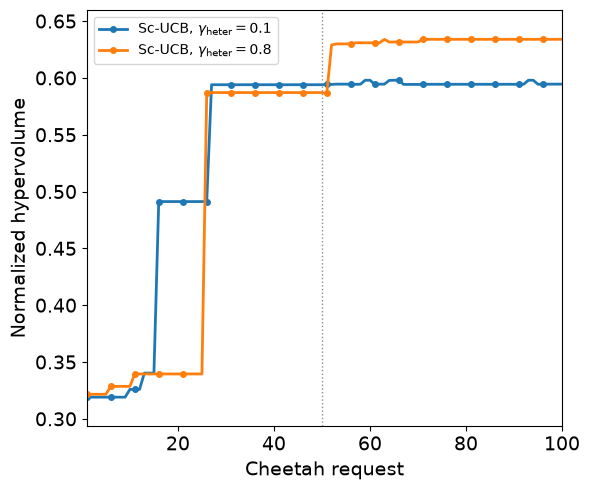

In [19]:
plot_ucb_hypervolume(ucb_results["reductionist_heterogeneity"], "STR")

## Final estimates

The recommended arms are normalized values for holistic experiments and physical Cheetah fitness margins for reductionist experiments.

In [20]:
rows = ["| Experiment | Approach | Formulation | Sweep value | Final hypervolume | Recommended arms |",
        "|---|---|---|---:|---:|---|"]
for record in ucb_results.values():
    for run in record["runs"].values():
        level = run.get("sweep_value", run.get("gravity_variance"))
        arms = record["arms"][run["recommended_arms"][-1]]
        selected = ", ".join(f"{value:.3f}" for value in arms)
        rows.append(f"| {record['experiment']} | {record['approach']} | {run['formulation']} | "
                    f"{level:g} | {run['hypervolume_history'][-1]:.6f} | {selected} |")
display(Markdown("\n".join(rows)))

| Experiment | Approach | Formulation | Sweep value | Final hypervolume | Recommended arms |
|---|---|---|---:|---:|---|
| gravity | holistic | RTS | 1 | 0.787648 | 0.111, 0.222, 0.333, 0.889, 1.000 |
| gravity | holistic | STR | 1 | 0.787103 | 0.111, 0.222, 0.333, 0.889, 1.000 |
| gravity | holistic | RTS | 5 | 0.768415 | 0.000, 0.111, 0.333, 0.667, 0.889 |
| gravity | holistic | STR | 5 | 0.760282 | 0.000, 0.111, 0.333, 0.667, 0.778 |
| gravity | reductionist | RTS | 1 | 0.584477 | -6.667, -3.333, 0.000, 3.333, 6.667 |
| gravity | reductionist | STR | 1 | 0.580097 | -6.667, -3.333, 0.000, 6.667 |
| gravity | reductionist | RTS | 5 | 0.568356 | -6.667, 0.000, 3.333, 6.667 |
| gravity | reductionist | STR | 5 | 0.563922 | -6.667, 0.000, 6.667 |
| synchronization | holistic | RTS | 1 | 0.796125 | 0.111, 0.333, 0.667, 0.889, 1.000 |
| synchronization | holistic | STR | 1 | 0.796020 | 0.111, 0.333, 0.667, 0.889, 1.000 |
| synchronization | holistic | RTS | 0.8 | 0.803847 | 0.111, 0.333, 0.778, 0.889 |
| synchronization | holistic | STR | 0.8 | 0.803740 | 0.111, 0.333, 0.778, 0.889 |
| synchronization | reductionist | RTS | 1 | 0.600130 | -3.333, 0.000, 3.333, 6.667 |
| synchronization | reductionist | STR | 1 | 0.598441 | -3.333, 3.333, 6.667 |
| synchronization | reductionist | RTS | 0.8 | 0.637349 | -10.000, 0.000, 3.333, 6.667 |
| synchronization | reductionist | STR | 0.8 | 0.636352 | -10.000, 0.000, 3.333, 6.667 |
| heterogeneity | holistic | RTS | 0.1 | 0.793550 | 0.111, 0.333, 0.889, 1.000 |
| heterogeneity | holistic | STR | 0.1 | 0.785669 | 0.111, 0.333, 0.667, 0.889 |
| heterogeneity | holistic | RTS | 0.8 | 0.792323 | 0.111, 0.333, 0.778, 1.000 |
| heterogeneity | holistic | STR | 0.8 | 0.792009 | 0.111, 0.333, 0.778, 1.000 |
| heterogeneity | reductionist | RTS | 0.1 | 0.599830 | -10.000, -3.333, 0.000, 3.333, 6.667 |
| heterogeneity | reductionist | STR | 0.1 | 0.594500 | -10.000, -3.333, 0.000, 6.667 |
| heterogeneity | reductionist | RTS | 0.8 | 0.634482 | -6.667, -3.333, 3.333, 6.667, 16.667 |
| heterogeneity | reductionist | STR | 0.8 | 0.633944 | -6.667, -3.333, 3.333, 6.667, 16.667 |

## Scalarized KG / Holistic gravity heterogeneity

Separate RTS and STR implementations follow the paper's Section 6.3.2 (Eqs. 49-52), using the cost length scalarization in Eq. 26. We compare gravity variances 1 and 5, with synchronization 1 and request-rate heterogeneity 0.5.

**10 arms, 5 directions, 150 global requests:** KG requires two observations per arm-direction pair, so the first 100 requests initialize its mean and variance estimates; the remaining 50 make adaptive KG choices. The dotted line marks request 100.

The **held-out horizon remains 100**, with the same fixed total-cost reference **(2,200,000 KiB, 310)**, sampled sequence design, two held-out realizations, and 128-direction hypervolume calculation as holistic UCB/MORBO/qNParEGO. All 150 checkpoints are displayed. Recommendations can change, so hypervolume is not forced to increase.

The online KG reference is a distinct **lower cost reference**, `[-0.01, -0.01]`, applied after dividing increments by their fixed bounds. KG minimizes max-length scalarized costs as specified in the paper. Existing UCB uses min-length scalarization of one-minus-cost rewards; these optimizer conventions are not equivalent for general directions. This single-run pilot investigates KG, and is not a controlled performance ranking. See [KG implementation details](../Scalarized%20Knowledge%20Gradient/README.md).

In [21]:
kg_dir = root / "Scalarized Knowledge Gradient"
kg_setup = json.loads((kg_dir / "setup_holistic_gravity.json").read_text(encoding="utf-8"))
with (kg_dir / kg_setup["output_file"]).open("rb") as file:
    kg_gravity = pickle.load(file)
if not kg_gravity["complete"] or kg_gravity["setup"] != kg_setup:
    raise ValueError("Finish/update the Scalarized KG holistic gravity script before plotting.")
for relative, expected in kg_gravity["source_sha256"].items():
    if hashlib.sha256((root / relative).read_bytes()).hexdigest() != expected:
        raise ValueError(f"KG results predate a source change: {relative}")
kg_xi = json.loads((kg_dir / kg_setup["xi_matrix_file"]).read_text(encoding="utf-8"))
if any(not np.array_equal(kg_gravity["xi_matrices"][name], values) for name, values in kg_xi.items()):
    raise ValueError("The Xi matrices changed; update the KG experiment before plotting.")


def plot_kg_gravity(formulation):
    all_hv = np.concatenate([np.asarray(run["hypervolume_history"]) for run in kg_gravity["runs"].values()])
    padding = max(0.005, 0.08 * np.ptp(all_hv))
    fig, ax = plt.subplots(figsize=(6, 5))
    for color, level in zip(["#1f77b4", "#ff7f0e"], kg_setup["gravity_variances"]):
        run = kg_gravity["runs"][f"{formulation}/gamma_grav={level:g}"]
        iterations = np.asarray(run["checkpoint_iterations"])
        values = np.asarray(run["hypervolume_history"])
        if len(values) != kg_setup["bandit"]["n_online_iterations"] or not run["complete"]:
            raise ValueError("Incomplete KG hypervolume trajectory")
        ax.plot(iterations, values, color=color, linewidth=2, marker="o", markersize=4,
                markevery=5, label=r"Sc-KG, $\gamma_{\mathrm{grav}} = " + f"{level:g}" + "$")
    initialization = (kg_setup["bandit"]["initial_pulls_per_pair"] * kg_setup["bandit"]["n_arms"]
                      * kg_setup["bandit"]["n_scalarization_directions"])
    ax.axvline(initialization, color="0.55", linestyle=":", linewidth=1)
    ax.set_xlabel("Global iteration", fontsize=14)
    ax.set_ylabel("Normalized hypervolume", fontsize=14)
    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.set_xlim(1, kg_setup["bandit"]["n_online_iterations"])
    ax.set_ylim(max(0, all_hv.min() - padding), all_hv.max() + padding)
    ax.grid(False)
    ax.legend(fontsize=10)
    fig.tight_layout()
    plt.show()


### KG / RTS: robustify, then scalarize

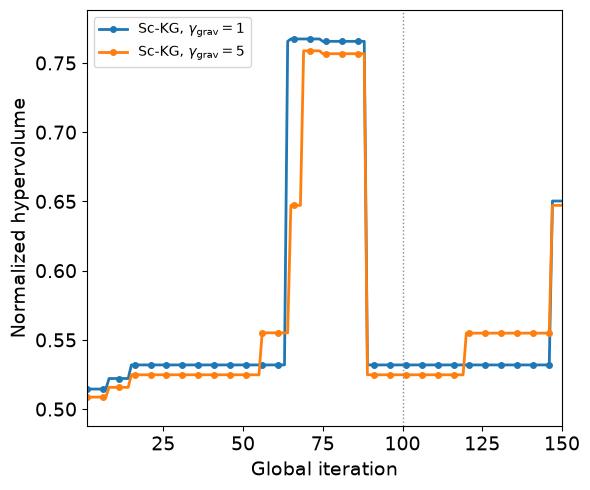

In [22]:
plot_kg_gravity("RTS")

### KG / STR: scalarize, then robustify

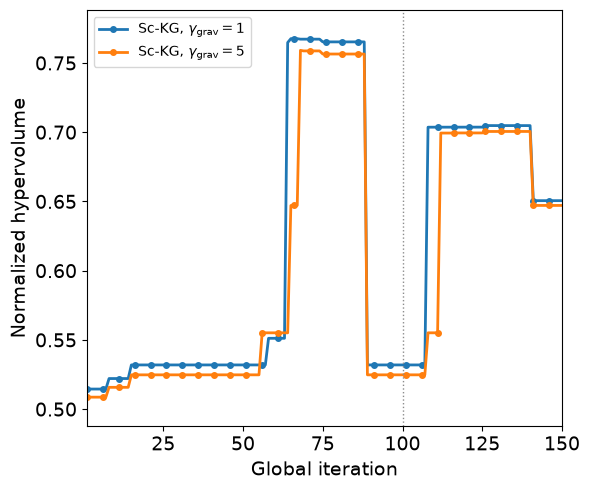

In [23]:
plot_kg_gravity("STR")

### KG pilot diagnostics

These counts cover the 50 adaptive requests. "KG choice differs from greedy" compares the selected arm with the empirical exploitation maximizer before observing that request. "Tied winning score" counts multiple exact maximizers of the KG score; ties choose the smallest arm index. In RTS, the paper's positive-part scalarization can produce ties when exploration bonuses move optimistic costs below the reference. Recommended arms are normalized values in [0, 1].

In [24]:
kg_rows = ["| Formulation | Gravity variance | HV after initialization | Final HV | KG choice differs from greedy | Tied winning score | Recommended arms |",
           "|---|---:|---:|---:|---:|---:|---|"]
for run in kg_gravity["runs"].values():
    decisions = run["adaptive_decisions"]
    changed = sum(run["arm_history"][d["iteration"] - 1] != np.argmax(d["exploitation_scores"]) for d in decisions)
    ties = sum(np.count_nonzero(d["scores"] == np.max(d["scores"])) > 1 for d in decisions)
    arms = kg_gravity["arms"][run["recommended_arms"][-1]]
    selected = ", ".join(f"{value:.3f}" for value in arms)
    initial_end = kg_setup["bandit"]["initial_pulls_per_pair"] * kg_setup["bandit"]["n_arms"] * kg_setup["bandit"]["n_scalarization_directions"]
    kg_rows.append(f"| {run['formulation']} | {run['sweep_value']:g} | "
                   f"{run['hypervolume_history'][initial_end-1]:.6f} | {run['hypervolume_history'][-1]:.6f} | "
                   f"{changed}/{len(decisions)} | {ties}/{len(decisions)} | {selected} |")
display(Markdown("\n".join(kg_rows)))


| Formulation | Gravity variance | HV after initialization | Final HV | KG choice differs from greedy | Tied winning score | Recommended arms |
|---|---:|---:|---:|---:|---:|---|
| RTS | 1 | 0.531903 | 0.650285 | 39/50 | 26/50 | 0.000, 0.111, 0.222, 0.444 |
| STR | 1 | 0.531901 | 0.650544 | 37/50 | 0/50 | 0.222, 0.333, 0.444 |
| RTS | 5 | 0.524769 | 0.647149 | 39/50 | 29/50 | 0.000, 0.111, 0.333, 0.444 |
| STR | 5 | 0.524738 | 0.647095 | 37/50 | 0/50 | 0.222, 0.333, 0.444 |